In [1]:
!pip install faiss-cpu langchain langchain-community langchain-core pypdf sentence-transformers transformers==4.52.4 torch 
!pip install -q bitsandbytes accelerate
!pip install pymupdf
!pip install pyngrok
!pip install PyPDF2

INFO: pip is looking at multiple versions of langchain-community to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 79.5 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 79.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 50.3 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 25.2 MB/s eta 0:00:0000:01m
  Attempting uninstall: packaging
    Found existing installation: packaging 26.0rc2
    Uninstalling packaging-26.0rc2:
      Successfully uninstalled packaging-26.0rc2
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.1
    Uninstalling tokenizers-0.22.1:
      Successfully uninstalled tokenizers-0.22.1
  Attempting uninstall: transformers
    Found existing installation: transformers

In [2]:
from langchain.vectorstores import FAISS
from langchain.embeddings import HuggingFaceEmbeddings
from langchain.document_loaders import PyPDFLoader
from langchain.docstore.document import Document
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain.llms.base import LLM
from langchain.prompts import PromptTemplate
from langchain.chains import LLMChain
from langchain_core.output_parsers import StrOutputParser
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from fastapi import FastAPI, Request, HTTPException
import uvicorn, threading, time, socket
from typing import Optional, List, Any
from pyngrok import ngrok, conf
from PyPDF2 import PdfReader
from PIL import Image
import matplotlib.pyplot as plt
import base64
import io
import fitz
import os
import re

In [3]:
pdf_path = "/kaggle/input/datasets/mohammadataallh/yolov4/YOLOv4.pdf"
loader = PyPDFLoader(pdf_path)
documents = loader.load()
len(documents)

17

In [32]:
pdf_path_2 = "/kaggle/input/datasets/mohammadataallh/gan-papaer/1.GAN.pdf"
loader = PyPDFLoader(pdf_path_2)
document_2= loader.load()
len(document_2)

9

In [5]:
def extract_equations_from_pdf(pdf_input):
    """
    pdf_input: can be a file path (str) or bytes
    """
    if isinstance(pdf_input, bytes):
        doc = fitz.open(stream=pdf_input, filetype="pdf")
    else:
        doc = fitz.open(pdf_input)

    equations = []

    for page_num in range(len(doc)):
        page = doc[page_num]
        blocks = page.get_text("blocks") 

        for block in blocks:
            text = block[4].strip()

            if any(sym in text for sym in ["=", "∫", "∑"]):
                text = re.sub(r"\n", " ", text)
                text = re.sub(r"\s+", " ", text)

                if len(text) < 500:
                    equations.append({
                        "page": page_num + 1,
                        "equation": text
                    })

    return equations

In [6]:
equations = extract_equations_from_pdf(pdf_path_2)

for eq in equations:
    print(f"Page {eq['page']}:")
    print(eq['equation'])
    print("-"*60)

Page 3:
min G max D V (D, G) = Ex∼pdata(x)[log D(x)] + Ez∼pz(z)[log(1 −D(G(z)))]. (1)
------------------------------------------------------------
Page 3:
We will show in section 4.1 that this minimax game has a global optimum for pg = pdata. We will then show in section 4.2 that Algorithm 1 optimizes Eq 1, thus obtaining the desired result.
------------------------------------------------------------
Page 4:
Algorithm 1 Minibatch stochastic gradient descent training of generative adversarial nets. The number of steps to apply to the discriminator, k, is a hyperparameter. We used k = 1, the least expensive option, in our experiments.
------------------------------------------------------------
Page 4:
i=1
------------------------------------------------------------
Page 4:
i=1 log  1 −D  G  z(i) .
------------------------------------------------------------
Page 4:
4.1 Global Optimality of pg = pdata
------------------------------------------------------------
Page 4:
D∗ G(x) = p

In [7]:
def extract_figures_from_pdf(pdf_bytes, save_dir="figures"):
    os.makedirs(save_dir, exist_ok=True)

    doc = fitz.open(stream=pdf_bytes, filetype="pdf")

    figures = []
    fig_counter = 1

    for page_index in range(len(doc)):
        page = doc[page_index]
        images = page.get_images(full=True)

        for img_index, img in enumerate(images):
            xref = img[0]
            base_image = doc.extract_image(xref)
            image_bytes = base_image["image"]

            image_path = f"{save_dir}/figure_{fig_counter}.png"

            with open(image_path, "wb") as f:
                f.write(image_bytes)

            figures.append((fig_counter, image_path))

            fig_counter += 1

    return figures

In [8]:
def show_figures(figures, cols=3):
    if not figures:
        print("No figures found.")
        return

    rows = (len(figures) + cols - 1) // cols

    plt.figure(figsize=(15, 5 * rows))

    for i, (fig_num, path) in enumerate(figures):
        img = Image.open(path)

        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.title(f"Figure {fig_num}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

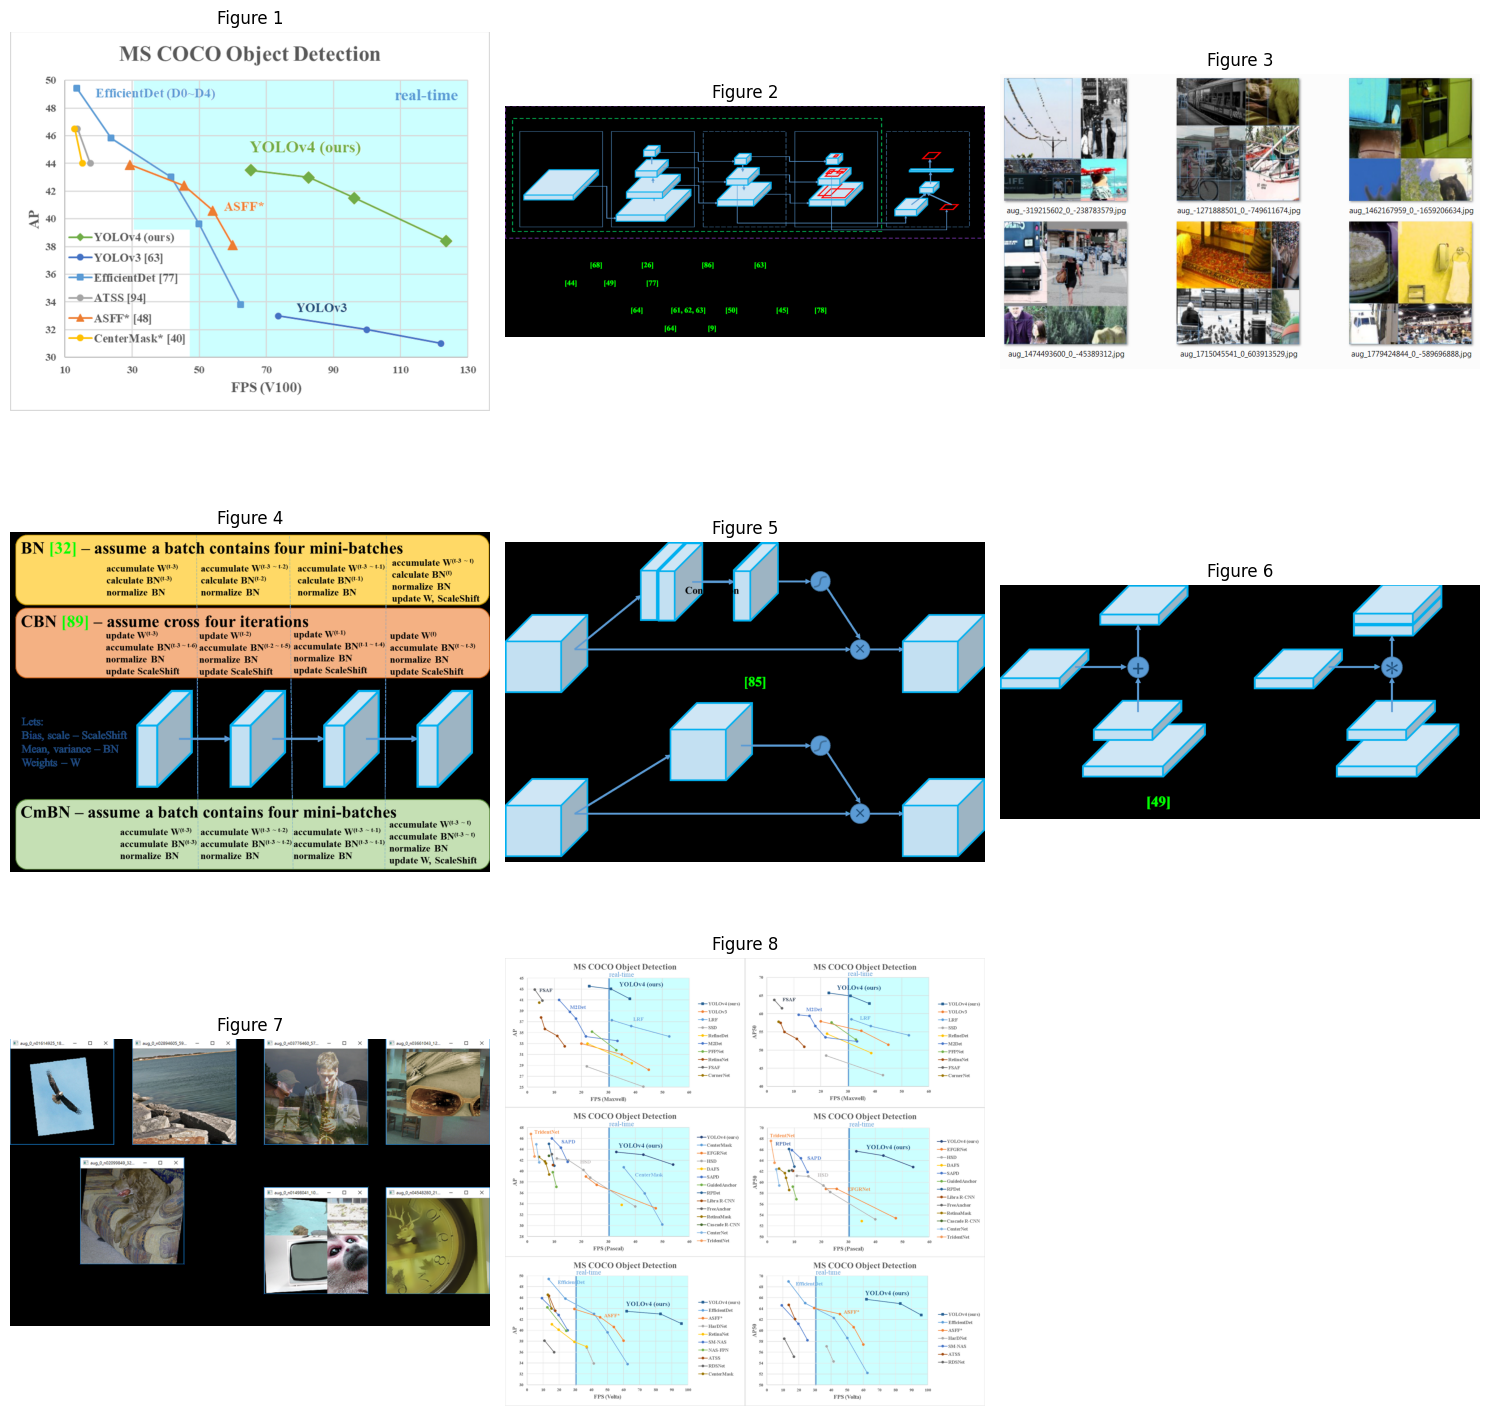

In [9]:
with open(pdf_path, "rb") as f:
    pdf_bytes = f.read()

figures = extract_figures_from_pdf(pdf_bytes)
show_figures(figures)

In [10]:
print(figures)

[(1, 'figures/figure_1.png'), (2, 'figures/figure_2.png'), (3, 'figures/figure_3.png'), (4, 'figures/figure_4.png'), (5, 'figures/figure_5.png'), (6, 'figures/figure_6.png'), (7, 'figures/figure_7.png'), (8, 'figures/figure_8.png')]


In [11]:
def remove_references_section(text):
    pattern = re.compile(
        r"\n\s*(references|bibliography|works cited|acknowledgments).*",
        re.IGNORECASE | re.DOTALL
    )
    return pattern.sub("", text).strip()

In [12]:
full_text = "\n".join([doc.page_content for doc in documents])
print(len(full_text))
cleaned_text = remove_references_section(full_text)
print(len(cleaned_text))
documents = [Document(page_content=cleaned_text)]

28916
22956


In [13]:
def split_text(docs):
    
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=1000,
        chunk_overlap=150,
        separators=["\n\n", "\n", ".", ";", ",", " ", ""],
    )
   
    texts = [doc.page_content for doc in docs]
    
    return splitter.create_documents(texts)

chunks = split_text(documents)
print("Number of chunks:", len(chunks))

Number of chunks: 27


In [14]:
embedding_model_name = "BAAI/bge-base-en-v1.5"

embedding = HuggingFaceEmbeddings(
    model_name=embedding_model_name,
    model_kwargs={"device": "cuda"},
    encode_kwargs={"normalize_embeddings": True}
)


vectordb = FAISS.from_documents(chunks, embedding)

/tmp/ipykernel_55/3071214884.py:3: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-huggingface package and should be used instead. To use it run `pip install -U :class:`~langchain-huggingface` and import as `from :class:`~langchain_huggingface import HuggingFaceEmbeddings``.
  embedding = HuggingFaceEmbeddings(
2026-03-04 15:19:12.475991: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772637552.818846      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772637552.926807      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has alread

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/366 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [15]:
model_name = "Qwen/Qwen2.5-7B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(
    model_name,
    trust_remote_code=True
)

bnb_cfg = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_quant_type="nf4",         
    bnb_4bit_use_double_quant=True     
)


model = AutoModelForCausalLM.from_pretrained(
    model_name,
    device_map="auto",
    quantization_config=bnb_cfg,
    trust_remote_code=True
)

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

...

model-00003-of-00004.safetensors:   0%|          | 0.00/3.86G [00:00<?, ?B/s]

model-00001-of-00004.safetensors:   0%|          | 0.00/3.95G [00:00<?, ?B/s]

model-00004-of-00004.safetensors:   0%|          | 0.00/3.56G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

In [16]:
def generate_text(prompt, max_new_tokens=512):

    messages = [
        {"role": "system", "content": "Answer briefly and directly."},
        {"role": "user", "content": prompt}
    ]

    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = tokenizer(text, return_tensors="pt").to(model.device)

    outputs = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=False,
        temperature = 0.1,
        repetition_penalty=1.2,
        eos_token_id=tokenizer.eos_token_id,
        pad_token_id=tokenizer.eos_token_id,
        early_stopping=True
    )

    new_tokens = outputs[0][inputs.input_ids.shape[-1]:]

    return tokenizer.decode(new_tokens, skip_special_tokens=True).strip()


In [17]:
class CustomHFLLM(LLM):
    """Wrapper for HuggingFace Transformers model to work with LangChain."""

    model: Any
    tokenizer: Any

    def _call(self, prompt: str, stop: Optional[List[str]] = None, **kwargs) -> str:
        max_new_tokens = kwargs.get("max_new_tokens", 500)  # افتراضي 500
        do_sample = kwargs.get("do_sample", True)
        top_p = kwargs.get("top_p", 0.9)
        temperature = kwargs.get("temperature", 0.1)

        inputs = self.tokenizer(prompt, return_tensors="pt").to(self.model.device)
        outputs = self.model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=do_sample,
            top_p=top_p,
            temperature=temperature
        )
        return self.tokenizer.decode(outputs[0], skip_special_tokens=True)

    @property
    def _identifying_params(self):
        return {"model_name": str(self.model.__class__)}

    @property
    def _llm_type(self):
        return "custom_hf_llm"



llm = CustomHFLLM(model=model, tokenizer=tokenizer)

In [18]:
def clean_llm_output(output, marker):
    text = output.content if hasattr(output, "content") else str(output)
    if marker in text:
        text = text.split(marker, 1)[1].strip()
    return text

# Summary

In [19]:
# Chain 1: introduction 
introduction_prompt = PromptTemplate(
    input_variables=["paper_text"],
    template="""
You are an AI research paper explainer.
Based on the text below, write a **concise and clear summary of the paper's introduction**.
Follow these rules:
1. Summarize the **background and context** of the research.
2. Explain the **problem or challenge** the paper addresses.
3. Highlight why this research is **important or needed**.
4. Use **simple and clear language** suitable for students or beginners.
5. Limit your summary to **3-5 sentences**.
6. Write **one coherent paragraph only**.
7. Respond **with the summary only**, do NOT repeat the instructions or the paper text.

Paper text:
{paper_text}

Write the Introduction summary:
"""
)


intro_chain =  introduction_prompt | llm | StrOutputParser()
retrieved_docs = vectordb.similarity_search("Introduction", k=2)
paper_text = "\n".join([doc.page_content for doc in retrieved_docs])

intro_output = intro_chain.invoke({"paper_text": paper_text})
intro_cleaned = clean_llm_output(intro_output, "Write the Introduction summary:")
print(intro_cleaned)

The introduction discusses the optimization of Generative Adversarial Networks (GANs) by maintaining the discriminator \(D\) close to its optimal solution while allowing the generator \(G\) to change slowly. It highlights the challenge of insufficient gradients for the generator early in training when the discriminator is confident in rejecting poor samples. To address this, the paper proposes training the generator to maximize the likelihood of real samples rather than minimizing the likelihood of fake ones. This approach ensures better synchronization between \(D\) and \(G\) and provides stronger gradients early in training. The introduction emphasizes the importance of this method for improving the efficiency and effectiveness of GAN training, particularly in avoiding issues like the "Helvetica scenario" where the generator collapses too much diversity. These improvements offer computational benefits and potentially enhance the statistical performance of GANs. The introduction sets 

In [20]:
# Chain 2: Related Work
related_work_prompt = PromptTemplate(
    input_variables=["paper_text"],
    template="""
You are an AI research paper explainer.
Based on the text below, write a **concise summary of the related work** mentioned in the research paper.
Follow these rules:
1. Summarize **previous studies or methods** related to the research.
2. Highlight the **limitations or gaps** in past work if mentioned.
3. Explain how this paper **differs from or improves upon** prior work.
4. Use **simple and clear language** suitable for students or beginners.
5. Keep it short and structured, in bullet points if helpful.

Paper text:
{paper_text}

Write the Related Work summary:
"""
)

related_work_chain = related_work_prompt | llm | StrOutputParser()
retrieved_docs = vectordb.similarity_search("Related work", k=3)
paper_text = "\n".join([doc.page_content for doc in retrieved_docs])

related_output = related_work_chain.invoke({"paper_text": paper_text} , max_new_tokens=1024)
related_cleaned = clean_llm_output(related_output, "Write the Related Work summary:")
print(related_cleaned)


- Previous studies often focused on discriminative models for tasks like classification.
- Generative models were less explored, especially using adversarial frameworks.
- Most visualizations of deep generative models showed conditional means rather than actual samples.
- The proposed method uses an adversarial framework without requiring Markov chains or unrolled approximate inference networks.
- It demonstrates potential through qualitative and quantitative evaluations of generated samples.
- This approach differs by providing actual samples from the model distribution, showing uncorrelated and diverse outputs. - Previous studies primarily concentrated on discriminative models for classification tasks.
- There was limited exploration of generative models, particularly using adversarial frameworks.
- Common visualizations of deep generative models typically displayed conditional means given hidden unit samples rather than true model-generated samples.
- The proposed method innovates b

In [21]:
# Chain 3: Explain Methodology
methodology_prompt = PromptTemplate(
    input_variables=["paper_text"],
    template="""
You are an AI research paper explainer.
Based on the text below, write a **clear and concise summary of the methodology** used in the research paper.
Follow these rules:
1. Explain the **main methods, techniques, or experiments** used.
2. Focus on the **overall approach**, not on every small technical detail.
3. Use **simple and clear language** suitable for students or beginners.
4. Structure the summary in **bullet points or short paragraphs** if helpful.
5. Keep it short and easy to understand.

Paper text:
{paper_text}

Write the Methodology summary:
"""
)

methods_chain = methodology_prompt | llm | StrOutputParser()
retrieved_docs = vectordb.similarity_search("Methodology", k=3)
paper_text = "\n".join([doc.page_content for doc in retrieved_docs])

methods_output = methods_chain.invoke({"paper_text": paper_text}, max_new_tokens=1024)
methods_cleaned = clean_llm_output(methods_output, "Write the Methodology summary:")
print(methods_cleaned)

The main methods and techniques used in this research include:

- **Cross-validation for hyperparameter tuning**: The study utilized cross-validation to determine the optimal value of σ (a hyperparameter) for the model. This was done separately for each fold of the dataset, ensuring that the model's performance was evaluated under different conditions.

- **Likelihood estimation via cross-validation**: For the TFD dataset, the researchers estimated the likelihood using cross-validation on each fold of the dataset. They also compared their model against others on the real-valued version of the MNIST dataset, focusing on the accuracy of likelihood estimation.

- **Training strategy for Generative Adversarial Networks (GANs)**: The paper describes a specific training strategy for GANs, where the discriminator (D) is kept close to its optimal solution while the generator (G) is allowed to change slowly. This is achieved by alternating between updating D and G, ensuring that D remains effec

In [22]:
# Chain 4: Explain Experiments
experiments_prompt = PromptTemplate(
    input_variables=["paper_text"],
    template="""
You are an AI research paper explainer.
Based on the text below, write a **clear and concise summary of the experiments** conducted in the research paper.
Follow these rules:
1. Describe **what experiments or tests were performed**.
2. Mention **datasets, metrics, or evaluation methods** used if available.
3. Highlight any **key findings or results** from the experiments.
4. Use **simple and clear language** suitable for students or beginners.
5. Keep it short and structured, using **bullet points** if helpful.

Paper text:
{paper_text}

Write the Experiments summary:
"""
)

experiments_chain = experiments_prompt | llm | StrOutputParser()
retrieved_docs = vectordb.similarity_search("Experiments", k=3)
paper_text = "\n".join([doc.page_content for doc in retrieved_docs])

experiments_output = experiments_chain.invoke({"paper_text": paper_text} , max_new_tokens=1024)
experiments_cleaned = clean_llm_output(experiments_output, "Write the Experiments summary:")
print(experiments_cleaned)

- Visualizations of samples from the model were shown in Figures 2 and 3.
- The samples were from different datasets including MNIST, TFD, CIFAR-10 (fully connected model), and CIFAR-10 (convolutional discriminator).
- The rightmost column in Figure 2 showed the nearest training example to demonstrate that the model had not memorized the training set.
- The samples were fair random draws, not cherry-picked, and were uncorrelated due to the sampling process not depending on Markov chain mixing.
- The experiments demonstrated the potential of the adversarial framework through qualitative and quantitative evaluations of the generated samples.
- No Markov chains or unrolled approximate inference networks were needed during training or generation of samples, only backpropagation was used.
- The generator and discriminator were trained together, with the generator not being updated directly with data examples but only with gradients flowing through the discriminator. - Visualizations of samp

In [23]:
# Chain 5: Highlight Results
results_prompt = PromptTemplate(
    input_variables=["paper_text"],
    template="""
You are an AI research paper explainer.

Write a **clear, concise, and structured summary of the key results** of the research paper. 

Guidelines:
1. Highlight the **main findings or outcomes**.
2. Explain **why these results are important or significant**.
3. Focus on **practical insights and implications**, not excessive technical details.
4. Use **simple and clear language** suitable for students or beginners.
5. Keep it short, ideally in **3-5 paragraphs**.
6. Start the output with a clear header like "### Summary of Key Results".
7. Do NOT repeat the paper text or the instructions.

Paper text:
{paper_text}

Write the Results summary:
"""
)



results_chain = results_prompt | llm | StrOutputParser()
retrieved_docs = vectordb.similarity_search("Results", k=3)
paper_text = "\n".join([doc.page_content for doc in retrieved_docs])

results_output = results_chain.invoke({"paper_text": paper_text})
results_cleaned = clean_llm_output(results_output, "Write the Results summary:")
print(results_cleaned)


### Summary of Key Results

The research paper presents several key findings related to evaluating generative models using a specific method for estimating log-likelihood. The authors compute the standard error of the log-likelihood across different folds of datasets, validating their approach through cross-validation techniques. They apply this method to both the MNIST and TFD datasets, comparing their results against other models. For MNIST, they also compare against models of the real-valued version of the dataset, highlighting the effectiveness of their approach in estimating the likelihood.

One of the main outcomes is the comparison of log-likelihood estimates for various models on the MNIST dataset. The table shows that adversarial networks achieve a mean log-likelihood of 225±2 on MNIST, outperforming other methods like Deep Belief Networks (DBNs) and Stacked Convolutional Autoencoders (CAEs). On the TFD dataset, the same method is used, but the standard error is calculated acr

# Q&A

In [24]:
chat_prompt = PromptTemplate(
    input_variables=["context", "question"],
template = """
You are an AI research assistant.

Answer the question using the following priority:
1. Use the information provided in the paper context.
2. If the paper context does not contain enough information, you may use your own knowledge.

Rules:
- Prefer answers from the paper whenever possible.
- If the answer is completely absent in the paper and you use your knowledge, indicate it clearly.
- Be clear and concise.
- Explain in simple language.

Paper Context:
{context}

Question:
{question}

Answer:
"""
)

chat_chain = chat_prompt | llm | StrOutputParser()

In [25]:
def ask_paper(question):

    docs = vectordb.similarity_search(question, k=5)
    context = "\n".join([doc.page_content for doc in docs])

    response = chat_chain.invoke(
        {"context": context, "question": question},
        max_new_tokens=1024
    )

    return clean_llm_output(response, "Answer:")
    

resulat = ask_paper('explain Anchor Optimization')
resulat

'The concept of "Anchor Optimization" is not explicitly mentioned or discussed in the provided paper context. The closest related concepts are the optimization of the generator (G) and discriminator (D) networks through alternating steps of updating each network. \n\nIn the paper, the optimization process involves alternating between multiple steps of updating the discriminator (D) and a single step of updating the generator (G). This is described as follows:\n\n1. The paper states: "Instead, we alternate between k steps of optimizing D and one step of optimizing G."\n\n2. It further explains: "This results in D being maintained near its optimal solution, so long as G changes slowly enough."\n\nHowever, these descriptions refer to the general optimization process of the GAN (Generative Adversarial Network) without using the term "Anchor Optimization." There isn\'t any specific mention or definition of "Anchor Optimization" in the given text.\n\nIf "Anchor Optimization" refers to a spec

# Diagram Explanation

In [26]:
figure_prompt_template = """
You are an AI research paper explainer.
Based on the figure description and its related context, write a **clear and concise explanation** of what the figure represents.
Follow these rules:
1. Describe the **main message or finding** of the figure.
2. Highlight important **trends, patterns, or anomalies** visible.
3. Explain how the figure **relates to the surrounding text** or the overall research question.
4. Mention any notable **comparisons, correlations, or insights**.
5. Use **bullet points or short paragraphs** to make it easy to read.
6. Keep the language **simple, clear, and suitable for students or researchers**.

Figure:
{figure_desc}

Context:
{context}

Write the explanation:
"""

figure_prompt = PromptTemplate(
    input_variables=["figure_desc", "context"],
    template=figure_prompt_template
)

In [27]:
def get_context_for_figure(figure_number, vectordb, top_k=3):

    query = f"Figure {figure_number}"
    docs = vectordb.similarity_search(query, k=top_k)
    context = "\n".join([doc.page_content for doc in docs])
    return context

In [28]:
import textwrap

def show_figures_with_explanations(figures, vectordb, chain):

    for fig_num, fig_path in figures:
        print("=" * 80)
        print("FIGURE PATH:", fig_path)

        img = Image.open(fig_path)
        plt.imshow(img)
        plt.axis("off")
        plt.show()

        context = get_context_for_figure(fig_num, vectordb)

        explanation = chain.invoke({
            "figure_desc": f"Figure {fig_num}",
            "context": context
        })

        explanation_cleaned = clean_llm_output(explanation, "Write the explanation:")


        wrapped_text = "\n".join(textwrap.wrap(explanation_cleaned, width=100))

        print("\nEXPLANATION:")
        print(wrapped_text)
        print("=" * 80)

FIGURE PATH: figures/figure_1.png


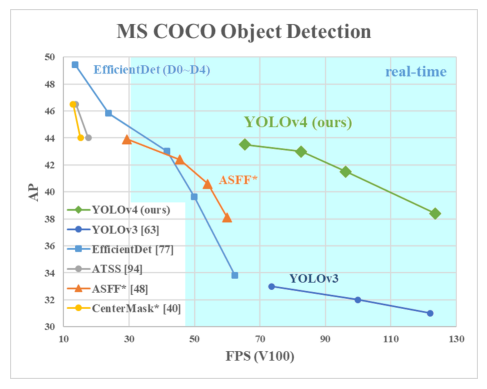


EXPLANATION:
The figure illustrates the visualization of samples generated by the model during training,
emphasizing that these samples are not cherry-picked but rather random draws from the model's
distribution. Here’s a detailed explanation:  - **Main Message**: The figure showcases samples from
the model, demonstrating that the model has learned to generate new, unseen data that are not simply
memorized from the training set. This highlights the potential of the adversarial framework used in
the model.  - **Trends, Patterns, or Anomalies**:    - **Randomness**: The samples shown are fair
random draws, indicating that the model is generating diverse and novel data rather than reproducing
specific examples from the training set.   - **Uncorrelated Samples**: The samples are uncorrelated,
meaning they do not depend on previous samples in a Markov chain, which is a significant advantage
over other methods.  - **Relation to Surrounding Text**:    - **MNIST, TFD, CIFAR-10**: The figure
s

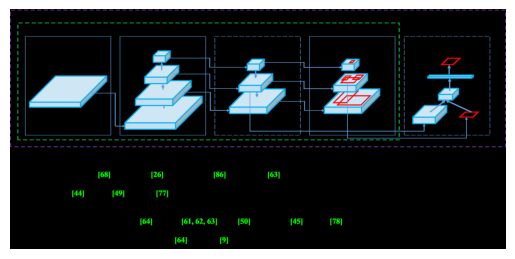


EXPLANATION:
The figure illustrates the visualization of samples generated by the model during training,
highlighting the potential of the adversarial framework. Here's a clear and concise explanation:  -
**Main Message**: The figure demonstrates that the model can generate realistic images without
memorizing the training set, indicating its ability to generalize well.  - **Trends and Patterns**:
- The rightmost column shows the nearest training example for each sample, demonstrating that the
model generates new, unseen data rather than reproducing existing ones.   - The samples are randomly
drawn, ensuring they represent the model's distribution rather than being selected for specific
characteristics.  - **Relationship to Surrounding Text**:   - It supports the claim that the model's
samples are competitive with other generative models in the literature.   - The figure emphasizes
the importance of the adversarial framework in producing diverse and realistic samples.  -
**Comparisons 

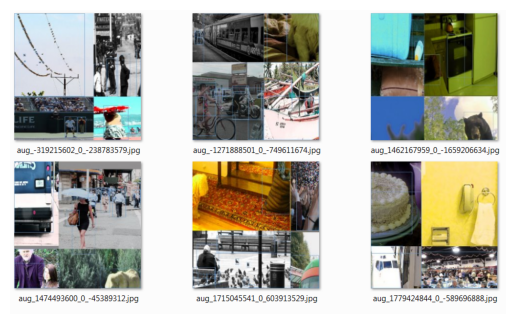


EXPLANATION:
The figure illustrates samples generated by the model after training, demonstrating the potential of
the adversarial framework. Here are the key points:  - **Main Message**: The figure showcases
samples from the model, indicating that the generated images are competitive with those produced by
other methods in the literature. This suggests the model can produce high-quality, realistic images
without simply memorizing the training set.  - **Trends and Patterns**:    - The rightmost column in
each subplot shows the nearest training example to the neighboring sample, highlighting that the
model has learned to generate new, unseen samples rather than just reproducing existing ones.   -
The samples are presented as random draws, ensuring they are not cherry-picked, which adds
credibility to the quality of the generated images.  - **Relation to Surrounding Text**:    - The
figure supports the claim made in the surrounding text that the model's samples are at least
competitive w

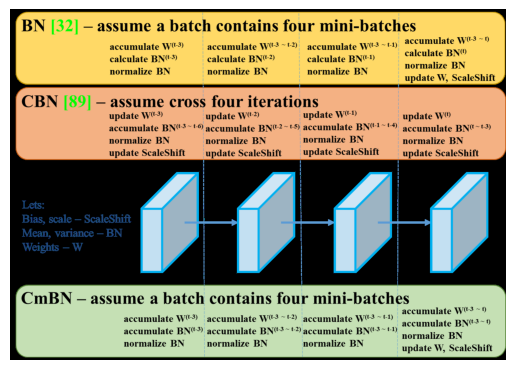


EXPLANATION:
The figure illustrates the quality and diversity of samples generated by the model compared to the
training set, highlighting the potential of the adversarial framework. Here's a clear and concise
explanation:  - The main message is that the model generates samples that are not just random noise
but are diverse and representative of the underlying data distribution. - Trends and patterns
include:   - The rightmost column shows the nearest training example for each sample, indicating
that the model hasn't memorized the training set.   - Samples are randomly drawn, ensuring a fair
representation of the model's output. - The figure relates to the surrounding text by demonstrating
that the model can produce high-quality, diverse samples without relying on the training set. -
Notable comparisons and insights:   - Unlike other visualizations, these images represent actual
samples from the model distribution rather than conditional means.   - The samples are uncorrelated
due to 

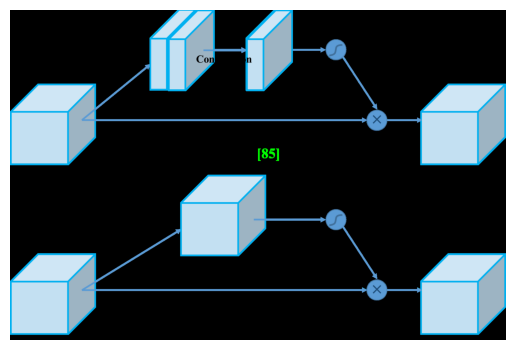


EXPLANATION:
The figure illustrates the quality and diversity of samples generated by the model, highlighting its
potential in the adversarial framework. Here are the key points:  - **Main Message**: The figure
demonstrates that the model generates samples that are visually similar to real data but are not
simply memorizing the training set. This suggests that the model has learned to generate new, unseen
data rather than just reproducing existing examples.  - **Trends and Patterns**:   - **MNIST (a)**:
The samples look like handwritten digits, indicating that the model can generate realistic images of
numbers.   - **TFD (b)**: The samples appear as colored images, showing that the model can generate
diverse and realistic images.   - **CIFAR-10 (fully connected model, c)**: The samples show images
of objects from the CIFAR-10 dataset, demonstrating the model's ability to generate images of
various objects.   - **CIFAR-10 (convolutional discriminator, d)**: Similar to (c), these sample

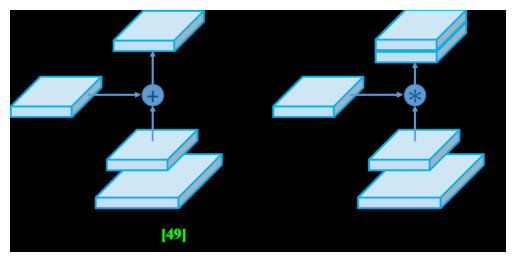


EXPLANATION:
The figure represents visualizations of samples generated by the model during training, specifically
for different datasets (MNIST, TFD, CIFAR-10 with fully connected and convolutional discriminators).
Here's a clear and concise explanation:  - **Main Message**: The figure demonstrates that the model
can generate realistic images that are not simply memorized from the training set but rather
represent new, unseen samples from the learned distribution.  - **Trends and Patterns**:   - The
rightmost column shows the nearest training example for each sample, indicating that the model
generates novel images rather than reproducing existing ones.   - The samples appear as fair random
draws, suggesting that the model does not favor certain types of images over others.  -
**Relationship to Surrounding Text**:   - The figure supports the claim made in the surrounding text
that the model's samples are competitive with those from other generative models.   - It highlights
the potent

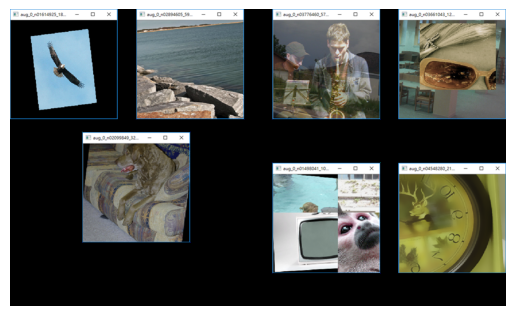


EXPLANATION:
The figure illustrates samples generated by the model during training, emphasizing that these
samples are not cherry-picked but rather random draws from the model's distribution. The main
message is that the model produces samples that are competitive with those from other generative
models, highlighting the potential of the adversarial framework.  - **Trends and Patterns:**   - The
samples shown in the figure (Figures 2a, 2b, 2c, and 2d) represent images from different datasets
(MNIST, TFD, CIFAR-10 with fully connected model, and CIFAR-10 with convolutional discriminator).
- The rightmost column in each figure shows the nearest training example to the neighboring sample,
demonstrating that the model has not memorized the training set.  - **Comparisons and Insights:**
- These samples are compared to those generated by other models, indicating that they are at least
competitive with the best models in the literature.   - The samples are uncorrelated and do not
depend on M

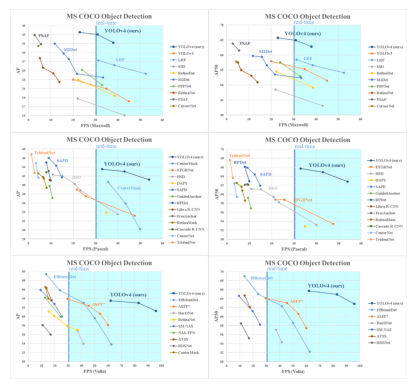


EXPLANATION:
The figure represents the visualization of samples generated by the model during training,
specifically for the datasets MNIST, TFD, CIFAR-10 (fully connected model), and CIFAR-10
(convolutional discriminator). Here are the key points:  - **Main Message**: The figure demonstrates
that the model can generate realistic images that are not simply memorized from the training set but
rather represent new, unseen samples from the learned distribution. - **Trends and Patterns**:    -
The rightmost column shows the nearest training example for each sample, indicating that the model
generates novel images rather than reproducing existing ones.   - The samples are presented as fair
random draws, highlighting that they are not cherry-picked.   - Unlike other visualizations, these
images are actual samples from the model distribution, not conditional means given hidden unit
samples.   - The samples are uncorrelated since the sampling process does not depend on Markov chain
mixing. - 

In [29]:
explanation_chain = figure_prompt | llm | StrOutputParser()

show_figures_with_explanations(figures, vectordb, explanation_chain)

# Math Equations

In [33]:
full_text = "\n".join([doc.page_content for doc in document_2])
print(len(full_text))
cleaned_text = remove_references_section(full_text)
print(len(cleaned_text))
document_2 = [Document(page_content=cleaned_text)]

28916
22956


In [34]:
chunks_2 = split_text(document_2)
print("Number of chunks:", len(chunks_2))

Number of chunks: 27


In [35]:
vectordb2 = FAISS.from_documents(chunks_2, embedding)

In [36]:
def clean_equation_for_prompt(equation):
    equation = equation.replace("pdata", "p_{data}")
    equation = equation.replace("pg", "p_g")
    equation = equation.replace("Ex∼", r"\mathbb{E}_{x \sim ")
    equation = equation.replace("Ez∼", r"\mathbb{E}_{z \sim ")
    return equation

In [37]:
def extract_latex(response_text):

    latex_eq = None
    explanation = response_text

   
    match = re.search(r"```latex(.*?)```", explanation, re.DOTALL)
    if match:
        latex_eq = match.group(1).strip()
        explanation = explanation.replace(match.group(0), "").strip()
    
  
    match2 = re.search(r"<latex>(.*?)</latex>", explanation, re.DOTALL)
    if match2:
        latex_eq = match2.group(1).strip()
        explanation = explanation.replace(match2.group(0), "").strip()
    
   
    explanation = re.sub(r"###\s*Clean LaTeX", "", explanation).strip()

    return latex_eq, explanation

In [38]:
def retrieve_context(equation, vectordb, k=3):
    docs = vectordb.similarity_search(equation, k=k)
    context = "\n\n".join([doc.page_content for doc in docs])
    return context

In [39]:
equation_prompt_template = """
You are a senior research professor.

Below is an equation extracted from an academic paper.

ORIGINAL EQUATION:
{equation}

Context:
{context}

Task:

1) Identify the TYPE of equation 
   (optimization, likelihood, divergence, theorem, gradient update, etc.)

2) Rewrite it in clean LaTeX inside:
<latex> ... </latex>

3) Provide structured explanation:

- Symbol Definitions
- Mathematical Meaning
- Role in the Paper
- Assumptions
- Implications & Behavior

Be rigorous, academic, and precise.
Write the explanation Equation:
"""

equation_prompt = PromptTemplate(
    input_variables=["equation", "context"],
    template=equation_prompt_template
)

equation_chain = equation_prompt | llm | StrOutputParser()

In [40]:
def explain_equation(equation, vectordb, llm_chain):
    
    cleaned_eq = clean_equation_for_prompt(equation)
    
    context = retrieve_context(equation, vectordb)
    
    response = llm_chain.invoke({"equation": cleaned_eq,"context": context})
    response_cleaned = clean_llm_output(response, "Write the explanation Equation:")
    latex_equation, response_cleaned = extract_latex(response_cleaned)
    
    return latex_equation , response_cleaned

In [41]:
from IPython.display import display, Math

for i in range(4):
    selected_equation = equations[i]["equation"]

    latex_eq, explanation = explain_equation(
        selected_equation,
        vectordb2,
        equation_chain
    )

    print("Equation:\n")
    if latex_eq:
        display(Math(latex_eq))
    else:
        print("No LaTeX found for this equation.")

    print("\nExplanation:\n")
    print(explanation)
    print("=" * 80)

Equation:



<IPython.core.display.Math object>


Explanation:

### Explanation:

#### Type of Equation:
This is an **optimization** equation, specifically a minimax optimization problem.

#:


#### Symbol Definitions:
- \( G \): Generator network parameterized by some set of parameters.
- \( D \): Discriminator network parameterized by some set of parameters.
- \( V(G,D) \): Value function that measures the performance of the generator and discriminator.
- \( p_{\text{data}}(x) \): Probability distribution of the real data.
- \( p_z(z) \): Probability distribution of the noise input to the generator.
- \( \mathbb{E}_{x \sim p_{\text{data}}(x)} \): Expectation over the real data distribution.
- \( \mathbb{E}_{z \sim p_z(z)} \): Expectation over the noise distribution.
- \( D(x) \): Discriminator output for real data \( x \).
- \( D(G(z)) \): Discriminator output for generated data \( G(z) \).

#### Mathematical Meaning:
The equation represents a minimax game where the generator \( G \) aims to minimize the expected log-discriminator 

<IPython.core.display.Math object>


Explanation:

### Type of Equation
The given equation is an **optimization** problem.




### Explanation

#### Symbol Definitions
- \( x \): A variable representing the input to the discriminator \( D \).
- \( p_{\text{data}}(x) \): The probability density function of the data distribution.
- \( p_g(x) \): The probability density function of the generated distribution.
- \( D(x) \): The output of the discriminator, which is a function mapping inputs to the interval \([0, 1]\).

#### Mathematical Meaning
The equation represents an integral over the input space \( x \) of a weighted sum of two terms:
1. \( p_{\text{data}}(x) \log(D(x)) \): This term measures how well the discriminator \( D \) distinguishes between real data points and the generated ones. It encourages \( D \) to assign higher values to real data points.
2. \( p_g(x) \log(1 - D(x)) \): This term measures how well the discriminator \( D \) distinguishes between generated data points and real ones. It encourages \( D \) t

<IPython.core.display.Math object>


Explanation:

V (G,D ) =
∫
x
pdata(x) log(D(x))dx +
∫
z
pz(z) log(1−D(g(z)))dz
=
∫
x
pdata(x) log(D(x)) +pg(x) log(1−D(x))dx (3)
### Type of Equation
**Type:** Theorem




### Explanation

#### Symbol Definitions
- \( V(G, D) \): The value function or objective function of the minimax game between the generator \( G \) and the discriminator \( D \).
- \( p_{\text{data}}(x) \): The probability density function of the real data distribution.
- \( p_z(z) \): The probability density function of the noise prior.
- \( g(z) \): The output of the generator when given a noise sample \( z \).
- \( D(x) \): The output of the discriminator when given a sample \( x \).

#### Mathematical Meaning
The equation represents the training criterion for the discriminator \( D \). It is a functional that measures how well the discriminator \( D \) can distinguish between real data samples \( x \) from the data distribution \( p_{\text{data}}(x) \) and generated samples \( g(z) \) from the generator \( G \)

# Deployment

In [42]:
from fastapi import FastAPI, Request, HTTPException
import uvicorn, threading, time, socket
from pyngrok import ngrok, conf
from PyPDF2 import PdfReader
import base64
import re
import io

In [43]:
NGROK_TOKEN = "39nq4ZH21jHBXtoi4DwgKf8ltUq_42fF2epHgbrR2TLiDh5ju"
API_KEY = "secret123"

In [44]:
def extract_text_from_bytes(pdf_bytes):
    pdf_file = io.BytesIO(pdf_bytes)
    reader = PdfReader(pdf_file)
    text = ""

    for page in reader.pages:
        content = page.extract_text()
        if content:
            text += content

    if not text.strip():
        raise Exception("No readable text found in PDF")

    text = remove_references_section(text)

    return text


In [45]:
def split_text(text):
    
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=1000,
        chunk_overlap=150,
        separators=["\n\n", "\n", ".", ";", ",", " ", ""],
    )
    
    return splitter.create_documents(text)

In [46]:
def build_vectordb(text):
    docs = split_text(text)
    vectordb = FAISS.from_documents(docs, embedding)
    return vectordb


In [47]:
def summarize_paper(vectordb):

    def run_chain(query, k, chain, marker):
        docs = vectordb.similarity_search(query, k=k)
        text = "\n".join([d.page_content for d in docs])

        raw_output = chain.invoke({"paper_text": text})

        cleaned = clean_llm_output(raw_output, marker)
        return cleaned

    return {
        "introduction": run_chain(
            "Introduction", 2, intro_chain,
            "Write the Introduction summary:"
        ),

        "related_work": run_chain(
            "Related work", 3, related_work_chain,
            "Write the Related Work summary:"
        ),

        "methodology": run_chain(
            "Methodology", 3, methods_chain,
            "Write the Methodology summary:"
        ),

        "experiments": run_chain(
            "Experiments", 3, experiments_chain,
            "Write the Experiments summary:"
        ),

        "results": run_chain(
            "Results", 3, results_chain,
            "Write the Results summary:"
        ),
    }

In [48]:
def ask_paper(question):
    global vectordb_2

    if vectordb_2 is None:
        return "Please upload a PDF first."

    docs = vectordb_2.similarity_search(question, k=5)
    context = "\n".join([doc.page_content for doc in docs])

    response = chat_chain.invoke(
        {"context": context, "question": question},
        max_new_tokens=1024
    )

    return clean_llm_output(response, "Answer:")

In [49]:
def generate_explanation_safe(fig_number):
    try:
        context = get_context_for_figure(fig_number, vectordb_2)
        explanation = explanation_chain.invoke({
            "figure_desc": f"Figure {fig_number}",
            "context": context
        })
        return clean_llm_output(explanation, "Write the explanation:")
    except Exception:
        return "Explanation could not be generated due to model error."

In [50]:
app = FastAPI()

vectordb_2 = None
pdf_bytes = None

@app.post("/summary")
async def rag(req: Request):
    try:
        global vectordb_2
        global pdf_bytes

        if req.headers.get("authorization") != f"Bearer {API_KEY}":
            raise HTTPException(status_code=401, detail="Unauthorized")

        data = await req.json()
        pdf = data.get("pdf_file")

        pdf_bytes = base64.b64decode(pdf)
        text = extract_text_from_bytes(pdf_bytes)

        vectordb_2 = build_vectordb(text)

        summaries = summarize_paper(vectordb_2)

        return {"summary": summaries}

    except Exception as e:
        return {"error": str(e)}



@app.post("/q&a")
async def qa_endpoint(req: Request):
    try:
    
        if req.headers.get("authorization") != f"Bearer {API_KEY}":
            raise HTTPException(status_code=401, detail="Unauthorized")

        data = await req.json()
        question = data.get("question")
        if not question:
            raise HTTPException(status_code=400, detail="Missing 'question' field")

        answer = ask_paper(question)

        return {"answer": answer}

    except Exception as e:
        return {"error": str(e)}



@app.post("/diagram_explanation")
async def diagram_explanation_endpoint(req: Request):

    global pdf_bytes
    global vectordb_2
    

    if req.headers.get("authorization") != f"Bearer {API_KEY}":
        raise HTTPException(status_code=401, detail="Unauthorized")

    try:
     
        if pdf_bytes is None or vectordb_2 is None:
            raise HTTPException(
                status_code=400,
                detail="PDF not processed yet. Call /summary first."
            )

        doc = fitz.open(stream=pdf_bytes, filetype="pdf")

        results = []
        fig_counter = 1
        seen_images = set()

        for page_index, page in enumerate(doc):

            images = page.get_images(full=True)

            for img_info in images:
                xref = img_info[0]

                if xref in seen_images:
                    continue
                seen_images.add(xref)

                pix = fitz.Pixmap(doc, xref)

                if pix.n - pix.alpha > 3:
                    pix = fitz.Pixmap(fitz.csRGB, pix)

                img_bytes = pix.tobytes("jpeg")
                img_base64 = base64.b64encode(img_bytes).decode("utf-8")

                explanation = generate_explanation_safe(fig_counter)

                results.append({
                    "figure_number": fig_counter,
                    "page_number": page_index + 1,
                    "figure_image": img_base64,
                    "explanation": explanation
                })

                fig_counter += 1

        if not results:
            raise HTTPException(
                status_code=400,
                detail="No figures detected in PDF."
            )

        return {"figures": results}

    except HTTPException:
        raise
    except Exception as e:
        print("DIAGRAM ERROR:", str(e))
        raise HTTPException(status_code=500, detail=str(e))


@app.post("/equation_explanation")
async def equation_explanation_endpoint(req: Request):

    global pdf_bytes
    global vectordb_2

    # Authorization check
    if req.headers.get("authorization") != f"Bearer {API_KEY}":
        raise HTTPException(status_code=401, detail="Unauthorized")

    try:
        if pdf_bytes is None or vectordb_2 is None:
            raise HTTPException(
                status_code=400,
                detail="PDF not processed yet. Call /summary first."
            )


        equations = extract_equations_from_pdf(pdf_bytes)

        if not equations:
            raise HTTPException(
                status_code=400,
                detail="No equations detected in PDF."
            )

     
        results = []
        for eq_obj in equations:
            eq_text = eq_obj["equation"]
            latex_eq, explanation = explain_equation(eq_text, vectordb_2, equation_chain)
            results.append({
                "page_number": eq_obj["page"],
                "equation_text": eq_text,
                "latex": latex_eq,
                "explanation": explanation
            })

        return {"equations": results}

    except HTTPException:
        raise
    except Exception as e:
        print("EQUATION ERROR:", str(e))
        raise HTTPException(status_code=500, detail=str(e))

In [ ]:
def free_port():
    s = socket.socket()
    s.bind(('', 0))
    port = s.getsockname()[1]
    s.close()
    return port

port = free_port()
conf.get_default().auth_token = NGROK_TOKEN
public_url = ngrok.connect(port).public_url
print("Your public URL:", public_url)

def run(): uvicorn.run(app, host="0.0.0.0", port=port)
threading.Thread(target=run, daemon=True).start()
time.sleep(1)